# Results of k=10 on the 10x Visium HD CRC dataset

In [7]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import os

import warnings
warnings.filterwarnings("ignore")

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import sys
sys.path.append(r'/import/home2/share/yqzeng/MacSGP/codes')
import MacSGP_additive

DATA_PATH = "/home/yzengbj/factor/data/CRC" # Raw data
SAVE_PATH = "/import/home2/share/yqzeng/MacSGP/results/CRC" # Deconvolution results
os.makedirs(os.path.join(SAVE_PATH), exist_ok = True)

In [8]:
import torch
model = torch.load(os.path.join(SAVE_PATH, "model_k=10.pt"))

In [9]:
adata_result = model.eval(sort_sgps=False)

In [10]:
ct_plot = ['CAF', 'Enterocyte', 'Goblet', 'Macrophage', 'Neutrophil', 'Plasma',
           'Proliferating Fibroblast', 'Tumor III', 'Tumor V', 'vSM']

In [11]:
variance_list = []
for ct in ct_plot:
    variation_ct = []
    for index in range(0, 11):
        variation = adata_result.obsm[ct].values[:, 0:index] @ adata_result.varm[ct].values[:, 0:index].T
        variation_ct.append((variation**2).mean())
    variance_ct = np.array(variation_ct)
    variance_ct = variance_ct / variance_ct[-1]
    variance_list.append(variance_ct)

# get increased variance from 1 to 10 SGPs
variance_explained = []
for variance_ct in variance_list:
    explained = variance_ct[1:] - variance_ct[:-1]
    variance_explained.append(explained)

# variance explained to dataframe
variance_explained_df = pd.DataFrame(variance_explained, index=ct_plot, columns=['SGP_{}'.format(i) for i in range(1, 11)])

In [6]:
basis = model.basis.detach().cpu().numpy()
gamma_k = model.net.gamma_k.detach().cpu().numpy()
basis = basis * np.exp(gamma_k)
proportion = model.proportion.detach().cpu().numpy()
u_exp = proportion @ basis
alpha = model.alpha.detach().cpu().numpy()
gamma = model.gamma.detach().cpu().numpy()
log_lam = np.log(u_exp + 1e-6) + alpha.reshape(-1, 1) + gamma.reshape(1, -1)
# compute decon_loss with log_lam
count = model.Y.detach().cpu().numpy()
library_size = count.sum(axis=1)
# decon_loss_null = - torch.mean(torch.sum(count * 
#                                         (torch.log(library_size + 1e-6) + log_lam) - library_size * torch.exp(log_lam), axis=1))
decon_loss_null = - np.mean(np.sum(count * (np.log(library_size.reshape(-1, 1) + 1e-6) + log_lam) - library_size.reshape(-1, 1) * np.exp(log_lam), axis=1))

# pick decon_loss for each round
decon_loss_all = model.decon_loss
decon_loss_ind = [decon_loss_all[i*3000-1] for i in range(1, 11)]
decon_loss_ind = [decon_loss_null] + decon_loss_ind
decon_loss_ind

[303.09256,
 275.7985420227051,
 266.5514831542969,
 260.9611701965332,
 258.5010223388672,
 255.78449630737305,
 253.45342254638672,
 251.4688491821289,
 250.13347244262695,
 248.8782958984375,
 247.84244537353516]

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import pearsonr
from libpysal.weights import KNN
import matplotlib as mpl

mpl.rcParams.update({
    'font.family': 'Helvetica', 
    'font.size': 7,
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'xtick.labelsize': 6.5,
    'ytick.labelsize': 6.5,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'pdf.fonttype': 42,  
    'ps.fonttype': 42,
    'savefig.dpi': 300,
    'figure.dpi': 150,
})

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

losses = np.array(decon_loss_ind)

total_improvement = losses[-1] - losses[0]
marginal_gains = np.diff(losses)
cumulative_pde = np.cumsum(marginal_gains / total_improvement * 100)
cumulative_pde = np.concatenate([[0], cumulative_pde])

fig, ax = plt.subplots(1, 1, figsize=(4, 3.5))

ax.plot(range(0, len(cumulative_pde)), cumulative_pde, 'o-',
        color='#2c3e50', markersize=5, linewidth=1.8,
        markerfacecolor='white', markeredgewidth=1.5)

# highlight K=1 as the elbow
ax.scatter([1], [cumulative_pde[1]], color='#d62728', s=60, zorder=5)
ax.annotate(f'K=1 ({cumulative_pde[1]:.0f}%)',
            xy=(1, cumulative_pde[1]),
            xytext=(2.5, cumulative_pde[1] - 15),
            arrowprops=dict(arrowstyle='->', color='#d62728', lw=1.2),
            color='#d62728', fontsize=10, fontweight='bold')

ax.set_xlabel('Number of SGPs (K)', fontsize=12)
ax.set_ylabel('Cumulative NLL improvement (%)', fontsize=12)
ax.set_xticks(range(0, len(cumulative_pde)))
ax.set_ylim(0, 110)
ax.tick_params(axis='both', labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
# plt.savefig('scree_plot_crc.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"CRC: K=1 cumulative = {cumulative_pde[1]:.1f}%, K=3 cumulative = {cumulative_pde[3]:.1f}%")

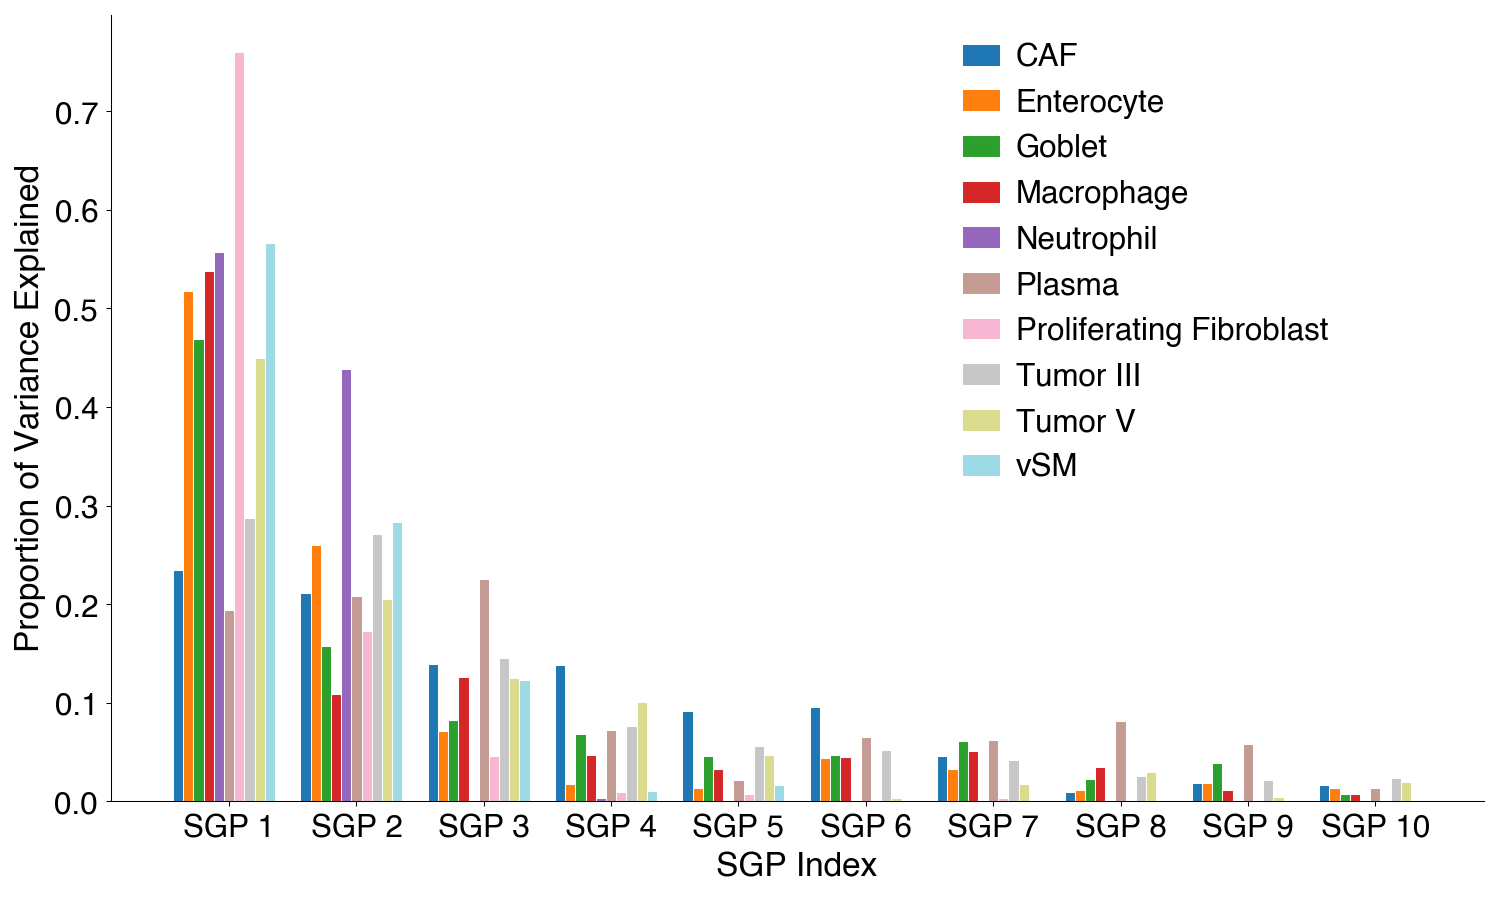

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

n_ct = len(ct_plot)
n_sgp = 10
bar_width = 0.8 / n_ct
index = np.arange(n_sgp)
cmap = plt.cm.get_cmap('tab20', n_ct)

for j in range(n_ct):
    explained_j = [variance_explained[j][i] for i in range(n_sgp)]
    ax.bar(index + j * bar_width, explained_j, bar_width,
           label=ct_plot[j], color=cmap(j), edgecolor='white', linewidth=0.5)

ax.set_xlabel('SGP Index', fontsize=16)
ax.set_ylabel('Proportion of Variance Explained', fontsize=16)
ax.set_xticks(index + bar_width * n_ct / 2)
ax.set_xticklabels([f'SGP {i+1}' for i in range(n_sgp)], fontsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(bbox_to_anchor=(0.60, 1), loc='upper left',
          frameon=False, fontsize=15, handlelength=1.2, handletextpad=0.5)

plt.tight_layout()
plt.show()

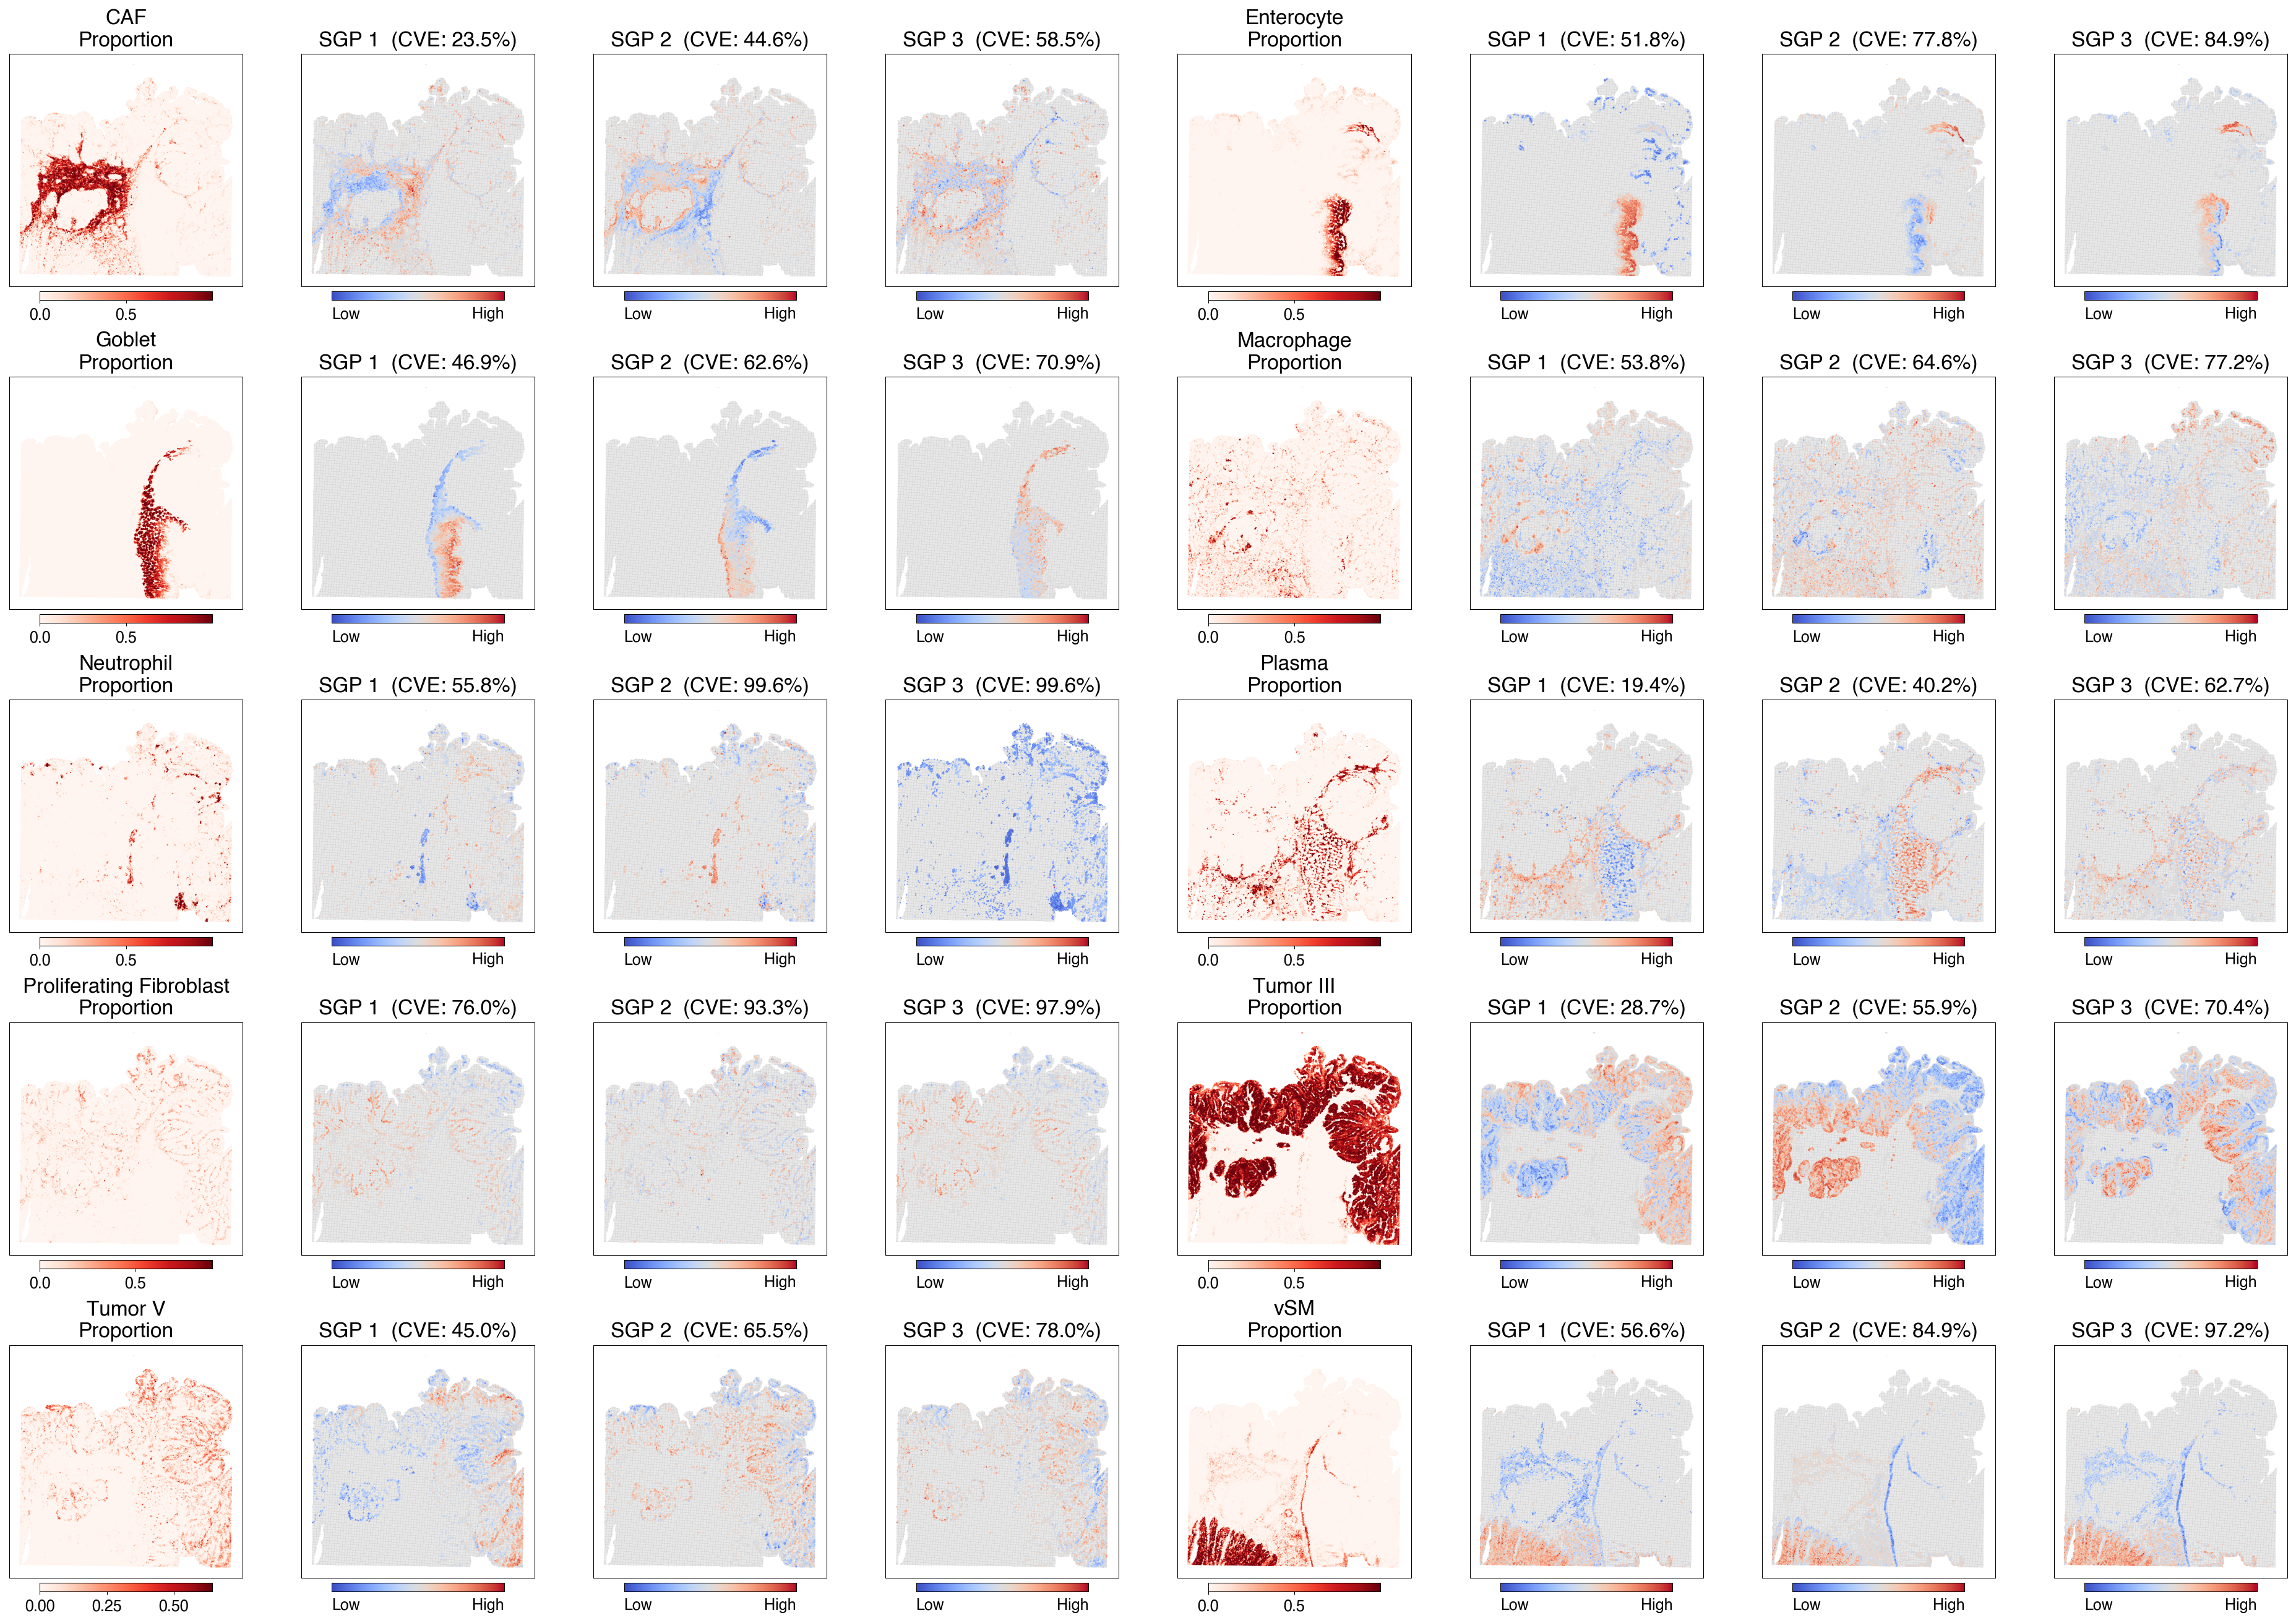

In [ ]:
import math

n_sgp          = 3
cols_per_ct    = n_sgp + 1        # proportion + SGP1..3
cts_per_row    = 2
prop_threshold = 0.1
cmap_sgp       = 'coolwarm'
cmap_prop      = 'Reds'
s_vis          = 1
s_masked       = 0.4

spatial = adata_result.obsm["spatial"]
cum_variance_df = variance_explained_df.cumsum(axis=1)
selected_cts = ct_plot

n_cts  = len(selected_cts)
n_rows = math.ceil(n_cts / cts_per_row)
n_cols = cols_per_ct * cts_per_row

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(3.2 * n_cols, 3.5 * n_rows),
                         squeeze=False)

for i, ct in enumerate(selected_cts):
    row        = i // cts_per_row
    col_offset = (i % cts_per_row) * cols_per_ct
    cum_row    = cum_variance_df.loc[ct].values
    prop       = adata_result.obsm['proportion'][ct].to_numpy()
    mask       = prop >= prop_threshold
    data       = adata_result.obsm[ct].values

    ax0  = axes[row, col_offset]
    sca0 = ax0.scatter(spatial[:, 0], -spatial[:, 1],
                       c=prop, s=s_vis, cmap=cmap_prop,
                       vmin=0, vmax=prop.max(),
                       rasterized=True, linewidths=0)
    cbar0 = fig.colorbar(sca0, ax=ax0, orientation='horizontal',
                         fraction=0.035, pad=0.02, shrink=0.6)
    cbar0.ax.tick_params(labelsize=12)
    ax0.set_title(f'{ct}\nProportion', fontsize=16)
    ax0.set_xticks([]); ax0.set_yticks([])
    ax0.set_aspect('equal', adjustable='box')
    for spine in ax0.spines.values():
        spine.set_linewidth(0.5)


    for j in range(n_sgp):
        ax      = axes[row, col_offset + j + 1]
        values  = data[:, j]
        norm_ij = mpl.colors.TwoSlopeNorm(vcenter=0.0)

        ax.scatter(spatial[~mask, 0], -spatial[~mask, 1],
                   c='lightgray', s=s_masked, alpha=0.4,
                   rasterized=True, linewidths=0)
        sca_j = ax.scatter(spatial[mask, 0], -spatial[mask, 1],
                           c=values[mask], s=s_vis, cmap=cmap_sgp,
                           norm=norm_ij, rasterized=True, linewidths=0)

        cbar_j = fig.colorbar(sca_j, ax=ax, orientation='horizontal',
                              fraction=0.035, pad=0.02, shrink=0.6)
        cbar_j.set_ticks([])
        cbar_j.ax.text(0.0, -0.8, 'Low',  ha='left',  va='top', fontsize=12,
                       transform=cbar_j.ax.transAxes)
        cbar_j.ax.text(1.0, -0.8, 'High', ha='right', va='top', fontsize=12,
                       transform=cbar_j.ax.transAxes)

        cum_pct = cum_row[j] * 100
        ax.set_title(f'SGP {j+1}  (CVE: {cum_pct:.1f}%)', fontsize=16)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_aspect('equal', adjustable='box')
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)

for i in range(n_cts, n_rows * cts_per_row):
    row        = i // cts_per_row
    col_offset = (i % cts_per_row) * cols_per_ct
    for j in range(cols_per_ct):
        axes[row, col_offset + j].set_visible(False)

plt.subplots_adjust(wspace=0.05, hspace=0.3)
plt.tight_layout()
plt.savefig(f'all_cts_top{n_sgp}_spatial.png', dpi=300, bbox_inches='tight')
plt.show()
